In [1]:
import requests
import psycopg2
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/alercebroker/usecases/master/alercereaduser_v4.json"
params = requests.get(url).json()['params']
conn = psycopg2.connect(dbname=params['dbname'], user=params['user'], host=params['host'], password=params['password'])

In [3]:
from sqlalchemy import create_engine
engine = create_engine(f"postgresql+psycopg2://{params['user']}:{params['password']}@{params['host']}/{params['dbname']}")

In [8]:
query = """
SELECT table_name FROM information_schema.tables
WHERE table_schema='alerce'
ORDER BY table_name;
"""
tables = pd.read_sql_query(query, engine)
tables.sort_values(by="table_name")

,table_name
0,alembic_version
1,allwise
2,dataquality
3,detection
4,feature
5,feature_version
6,forced_photometry
7,gaia_ztf
8,lc_classifier
9,lc_classifier_beta


In [13]:
query_xmatches = """
SELECT * FROM step
LIMIT 30;
"""
xmatches = pd.read_sql_query(query_xmatches, engine)

In [15]:
xmatches

,step_id,name,version,comments,date
0,features,features,feature_0.0.1,,2021-01-28
1,stamp_classification,stamp_classification,late_classification_0.0.1,,2021-01-28
2,preprocess,preprocess,correction_0.0.1,,2021-01-28
3,lc_classification,late classification,lc_classifier_0.0.1,,2021-01-28
4,xmatch_0.0.1,xmatch_0.0.1,xmatch_0.0.1,,2021-01-28
5,feature_0.0.1,features,feature_0.0.1,,2021-02-01
6,correction_1.0.6,preprocess,correction_1.0.6,,2021-07-22
7,transitional_features,features,1.0.0,,2022-05-27
8,feature_1.2.1,features,feature_1.2.1,,2021-07-22
9,feature_1.2.0,features,feature_1.2.0,,2021-07-22


In [15]:
query_periodic = """
SELECT * FROM lc_classifier_periodic
WHERE 
ranking in (1,2)
AND
probability > 0.6
LIMIT 10;
"""

lc_classifier_periodic = pd.read_sql_query(query_periodic, engine)

In [16]:
lc_classifier_periodic = lc_classifier_periodic.drop_duplicates(subset=['oid'])

In [17]:
lc_classifier_periodic

,oid,classifier_name,classifier_version,class_name,probability,ranking
0,ZTF18abrjkvt,lc_classifier_periodic,hierarchical_rf_1.1.0,Periodic-Other,0.680,1
1,ZTF17aaaaasb,lc_classifier_periodic,hierarchical_rf_1.1.0,E,0.772,1
2,ZTF19abkalqp,lc_classifier_periodic,hierarchical_rf_1.1.0,Periodic-Other,0.684,1
3,ZTF18abcvany,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.836,1
4,ZTF18aamqxgv,lc_classifier_periodic,hierarchical_rf_1.1.0,Periodic-Other,0.840,1
5,ZTF20aasprzc,lc_classifier_periodic,hierarchical_rf_1.1.0,Periodic-Other,0.678,1
6,ZTF21aaiugxn,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.804,1
7,ZTF18abijwdz,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.772,1
8,ZTF18ablrabh,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.754,1
9,ZTF20abdyvpg,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.646,1


In [18]:
oids = lc_classifier_periodic['oid'].tolist()[:10]

In [19]:
lc_classifier_periodic.value_counts('class_name')

class_name
LPV               5
Periodic-Other    4
E                 1
Name: count, dtype: int64

In [20]:
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from sqlalchemy import create_engine

BATCH_SIZE = 1000


def fetch_fp_data_batch(oids_batch):
    oids_str = "', '".join(oids_batch)
    fp_data_query = f'''
    SELECT * FROM detection
    WHERE 
    oid IN ('{oids_str}')
    '''
    fp_data = pd.read_sql_query(fp_data_query, conn)
    return fp_data

# Generator to split oids into batches
def batch_oids(oids, batch_size):
    for i in range(0, len(oids), batch_size):
        yield oids[i:i + batch_size]

# Initialize an empty DataFrame to store the final results
fp_df = pd.DataFrame()

# Parallelize fetching the data with progress tracking
with ThreadPoolExecutor(max_workers=8) as executor:  # Adjust the number of workers based on your machine
    # Use tqdm to wrap the batched oids for progress tracking
    for fp_data in tqdm(executor.map(fetch_fp_data_batch, batch_oids(oids, BATCH_SIZE)), total=len(oids) // BATCH_SIZE + 1):
        # Incrementally append results to the final dataframe
        fp_df = pd.concat([fp_df, fp_data], ignore_index=True)

# The result is a single concatenated DataFrame `fp_df` fetched in parallel batches


/tmp/ipykernel_193810/2502231410.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fp_data = pd.read_sql_query(fp_data_query, conn)
  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.24it/s]


In [21]:
fp_df

,oid,candid,mjd,fid,pid,diffmaglim,isdiffpos,nid,ra,dec,...,sigmagapbig,rfid,magpsf_corr,sigmapsf_corr,sigmapsf_corr_ext,corrected,dubious,parent_candid,has_stamp,step_id_corr
0,ZTF17aaaaasb,524447461915010022,58278.447465,2,524447461915,20.748500,-1,524,326.109129,45.998860,...,0.0269,NaN,16.652930,100.000000,0.007828,True,False,5.514534e+17,False,bulk_1.0.0
1,ZTF17aaaaasb,525449491915010021,58279.449491,1,525449491915,20.496800,-1,525,326.109177,45.998890,...,0.0672,NaN,17.798096,100.000000,0.019789,True,False,5.514534e+17,False,bulk_1.0.0
2,ZTF17aaaaasb,526428191915015151,58280.428194,1,526428191915,20.992100,1,526,326.109085,45.998848,...,0.1507,NaN,17.194292,100.000000,0.010051,True,False,5.514534e+17,False,bulk_1.0.0
3,ZTF17aaaaasb,526469201915010016,58280.469201,2,526469201915,20.791000,-1,526,326.109101,45.998858,...,0.0250,NaN,16.697813,100.000000,0.007978,True,False,5.514534e+17,False,bulk_1.0.0
4,ZTF17aaaaasb,527433921915015032,58281.433924,1,527433921915,20.926800,1,527,326.109164,45.998879,...,0.1967,NaN,17.189240,100.000000,0.010458,True,False,5.514534e+17,False,bulk_1.0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,ZTF21aaiugxn,2663383023915015034,60417.383021,2,2663383023915,19.507353,1,2663,285.991342,-1.971213,...,0.0582,436120239.0,14.946114,100.000000,0.006786,True,False,NaN,True,24.4.1
1004,ZTF21aaiugxn,2663383023915015035,60417.383021,2,2663383023915,19.507353,1,2663,285.991384,-1.971351,...,0.0879,436120239.0,14.909579,0.017989,0.025239,True,False,NaN,True,24.4.1
1005,ZTF21aaiugxn,2663411923915015018,60417.411921,1,2663411923915,20.077017,1,2663,285.991304,-1.971234,...,0.1747,436120139.0,17.219297,0.023415,0.026406,True,False,NaN,True,24.4.1
1006,ZTF21aaiugxn,2689439253915015025,60443.439259,1,2689439253915,20.304700,1,2689,285.991233,-1.971229,...,0.4387,NaN,17.327602,0.014853,0.020063,True,False,2.706420e+18,False,24.5.1


In [22]:
fp_df.keys()

Index(['oid', 'candid', 'mjd', 'fid', 'pid', 'diffmaglim', 'isdiffpos', 'nid',
       'ra', 'dec', 'magpsf', 'sigmapsf', 'magap', 'sigmagap', 'distnr', 'rb',
       'rbversion', 'drb', 'drbversion', 'magapbig', 'sigmagapbig', 'rfid',
       'magpsf_corr', 'sigmapsf_corr', 'sigmapsf_corr_ext', 'corrected',
       'dubious', 'parent_candid', 'has_stamp', 'step_id_corr'],
      dtype='object')

In [21]:
#data with valuecount of oid >12
#fp_df = fp_df[fp_df['procstatus'] == '0']
fp_df = fp_df[fp_df['oid'].map(fp_df['oid'].value_counts()) > 12]


In [22]:
fp_df

,oid,candid,mjd,fid,pid,diffmaglim,isdiffpos,nid,ra,dec,...,sigmagapbig,rfid,magpsf_corr,sigmapsf_corr,sigmapsf_corr_ext,corrected,dubious,parent_candid,has_stamp,step_id_corr
0,ZTF17aaaaasb,524447461915010022,58278.447465,2,524447461915,20.748500,-1,524,326.109129,45.998860,...,0.0269,NaN,16.652930,100.0,0.007828,True,False,5.514534e+17,False,bulk_1.0.0
1,ZTF17aaaaasb,525449491915010021,58279.449491,1,525449491915,20.496800,-1,525,326.109177,45.998890,...,0.0672,NaN,17.798096,100.0,0.019789,True,False,5.514534e+17,False,bulk_1.0.0
2,ZTF17aaaaasb,526428191915015151,58280.428194,1,526428191915,20.992100,1,526,326.109085,45.998848,...,0.1507,NaN,17.194292,100.0,0.010051,True,False,5.514534e+17,False,bulk_1.0.0
3,ZTF17aaaaasb,526469201915010016,58280.469201,2,526469201915,20.791000,-1,526,326.109101,45.998858,...,0.0250,NaN,16.697813,100.0,0.007978,True,False,5.514534e+17,False,bulk_1.0.0
4,ZTF17aaaaasb,527433921915015032,58281.433924,1,527433921915,20.926800,1,527,326.109164,45.998879,...,0.1967,NaN,17.189240,100.0,0.010458,True,False,5.514534e+17,False,bulk_1.0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16094244,ZTF21abpuzhi,2756334140415015008,60510.334143,2,2756334140415,19.284933,1,2756,306.136661,-19.346044,...,0.1004,337120204.0,15.097995,100.0,0.008559,True,False,NaN,True,24.5.1
16094245,ZTF21abpuzhi,2796344120415015012,60550.344120,1,2796344120415,19.934700,1,2796,306.136780,-19.346150,...,0.0453,NaN,15.175550,100.0,0.007210,True,False,2.823279e+18,False,24.5.1
16094246,ZTF21abpuzhi,2798329280415010012,60552.329282,1,2798329280415,19.956300,-1,2798,306.136795,-19.345970,...,0.0832,NaN,15.430573,100.0,0.008689,True,False,2.823279e+18,False,24.5.1
16094247,ZTF21abpuzhi,2817275060415015004,60571.275069,1,2817275060415,18.716000,1,2817,306.136785,-19.346169,...,0.2028,NaN,15.198757,100.0,0.009994,True,False,2.823279e+18,False,24.5.1


In [23]:
fp_df_unique_oid = fp_df.drop_duplicates(subset=['oid'])['oid'].values

In [24]:
lc_classifier_periodic_filtered_20000_unique_oid = lc_classifier_periodic_filtered_20000[lc_classifier_periodic_filtered_20000['oid'].isin(fp_df_unique_oid)]

In [25]:
lc_classifier_periodic_filtered_20000_unique_oid.value_counts('class_name')

class_name
E                 19924
RRL               19920
LPV               18825
Periodic-Other    18756
DSCT               8721
CEP                2119
Name: count, dtype: int64

In [26]:
lc_classifier_periodic_filtered_20000_unique_oid

,oid,classifier_name,classifier_version,class_name,probability,ranking
0,ZTF18abidhoe,lc_classifier_periodic,hierarchical_rf_1.1.0,LPV,0.514,1
1,ZTF18abrjkvt,lc_classifier_periodic,hierarchical_rf_1.1.0,Periodic-Other,0.680,1
2,ZTF18adlvixn,lc_classifier_periodic,hierarchical_rf_1.1.0,E,0.554,1
3,ZTF17aaaaasb,lc_classifier_periodic,hierarchical_rf_1.1.0,E,0.772,1
4,ZTF19abkalqp,lc_classifier_periodic,hierarchical_rf_1.1.0,Periodic-Other,0.684,1
...,...,...,...,...,...,...
902101,ZTF21abbxnqt,lc_classifier_periodic,hierarchical_rf_1.1.0,CEP,0.594,1
902403,ZTF21abedsmw,lc_classifier_periodic,hierarchical_rf_1.1.0,DSCT,0.586,1
902751,ZTF21abjtwib,lc_classifier_periodic,hierarchical_rf_1.1.0,DSCT,0.506,1
902861,ZTF21ablqtkl,lc_classifier_periodic,hierarchical_rf_1.1.0,DSCT,0.514,1


In [36]:
from alerce.core import Alerce

In [37]:
client = Alerce()

In [38]:
lc = client.query_lightcurve('ZTF18abbuksn',format='pandas')

In [39]:
features = client.query_features('ZTF18abbuksn', format='pandas')

In [52]:
clean_features = features[features['version']=='27.5.6']
#remove the row that starts with ulens
clean_features

,name,value,fid,version
2662,g-r_mean,2.419260,12,27.5.6
2663,g-r_max,2.166608,12,27.5.6
2664,g-r_mean_corr,2.488330,12,27.5.6
2665,g-r_max_corr,1.882486,12,27.5.6
2666,W1-W2,0.406000,0,27.5.6
...,...,...,...,...
2866,ulens_mag0,14.213249,2,27.5.6
2867,mean_distnr,0.141696,12,27.5.6
2868,sigma_distnr,0.106166,12,27.5.6
2869,mean_sharpnr,-0.040624,12,27.5.6


In [53]:

rm_feat = [
    "TDE_mag0",
    "fleet_t0",
    "fleet_m0",
    "ulens_t0",
    "ulens_mag0"
]

In [54]:
clean_features = clean_features[~clean_features['name'].isin(rm_feat)]

In [55]:
clean_features

,name,value,fid,version
2662,g-r_mean,2.419260,12,27.5.6
2663,g-r_max,2.166608,12,27.5.6
2664,g-r_mean_corr,2.488330,12,27.5.6
2665,g-r_max_corr,1.882486,12,27.5.6
2666,W1-W2,0.406000,0,27.5.6
...,...,...,...,...
2864,ulens_chi,1212.808298,2,27.5.6
2867,mean_distnr,0.141696,12,27.5.6
2868,sigma_distnr,0.106166,12,27.5.6
2869,mean_sharpnr,-0.040624,12,27.5.6


In [25]:
import pandas as pd
lc = pd.DataFrame(lc['detections'][0])

In [27]:
lc.columns

Index(['tid', 'mjd', 'candid', 'fid', 'pid', 'diffmaglim', 'isdiffpos', 'nid',
       'distnr', 'magpsf', 'magpsf_corr', 'magpsf_corr_ext', 'magap',
       'magap_corr', 'sigmapsf', 'sigmapsf_corr', 'sigmapsf_corr_ext',
       'sigmagap', 'sigmagap_corr', 'ra', 'dec', 'rb', 'rbversion', 'drb',
       'magapbig', 'sigmagapbig', 'rfid', 'has_stamp', 'corrected', 'dubious',
       'candid_alert', 'step_id_corr', 'phase', 'parent_candid'],
      dtype='object')

In [30]:
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# Function to fetch periods for a single oid
def fetch_periods(oid):
    try:
        period = client.query_feature(oid, 'Multiband_period', format='pandas')
        #add oid to the period dataframe
        period['oid'] = oid
        return period
    except:
        try:
            period = client.query_feature(oid, 'Multiband_period', format='pandas')
            #add oid to the period dataframe
            period['oid'] = oid
            return period
        except:
            try:
                period = client.query_feature(oid, 'Multiband_period', format='pandas')
                #add oid to the period dataframe
                period['oid'] = oid
                return period
            except:
                try:
                    period = client.query_feature(oid, 'Multiband_period', format='pandas')
                    #add oid to the period dataframe
                    period['oid'] = oid
                    return period
                except:
                    print(f"Error fetching period for oid: {oid}")

# List to store all periods
all_periods = []

# Parallelize fetching the periods with progress tracking
with ThreadPoolExecutor(max_workers=10) as executor:  # Adjust the number of workers based on your machine
    futures = {executor.submit(fetch_periods, oid): oid for oid in period_oid}
    for future in tqdm(as_completed(futures), total=len(futures)):
        result = future.result()
        if result is not None:
            all_periods.append(result)

# Concatenate all results into a single DataFrame if needed
if all_periods:
    all_periods_df = pd.concat(all_periods, ignore_index=True)

100%|██████████| 88265/88265 [23:28<00:00, 62.65it/s]


In [31]:
all_periods_df_filtered = all_periods_df[all_periods_df['version']=='lc_classifier_1.2.1-P']

In [32]:
oids_faltantes = lc_classifier_periodic_filtered_20000_unique_oid[~lc_classifier_periodic_filtered_20000_unique_oid['oid'].isin(all_periods_df_filtered['oid'].values)]['oid'].values

In [33]:
all_periods_df_filtered_2 = all_periods_df[all_periods_df['oid'].isin(oids_faltantes)]

In [34]:
all_periods_df_filtered_2_filtered = all_periods_df_filtered_2[all_periods_df_filtered_2['version']=='lc_classifier_1.2.1-P-transitional']

In [35]:
all_periods_true = pd.concat([all_periods_df_filtered, all_periods_df_filtered_2_filtered], ignore_index=True)

In [36]:
all_periods_true.dropna()

,name,value,fid,version,oid
0,Multiband_period,0.175853,12,lc_classifier_1.2.1-P,ZTF21aaiugxn
1,Multiband_period,0.126711,12,lc_classifier_1.2.1-P,ZTF17aaaaasb
2,Multiband_period,29.096477,12,lc_classifier_1.2.1-P,ZTF18abijwdz
3,Multiband_period,0.100721,12,lc_classifier_1.2.1-P,ZTF21aasxbqh
4,Multiband_period,575.757579,12,lc_classifier_1.2.1-P,ZTF18aamqxgv
...,...,...,...,...,...
88260,Multiband_period,0.068705,12,lc_classifier_1.2.1-P-transitional,ZTF18abfwwbk
88261,Multiband_period,0.217344,12,lc_classifier_1.2.1-P-transitional,ZTF18adizksm
88262,Multiband_period,0.222916,12,lc_classifier_1.2.1-P-transitional,ZTF18aaohywi
88263,Multiband_period,0.093536,12,lc_classifier_1.2.1-P-transitional,ZTF23aacsuey


In [37]:
fp_df.to_parquet('/home/fsoto/Documents/LCsSSL/data/detections_adquired.parquet')

In [38]:
all_periods_true.to_parquet('/home/fsoto/Documents/LCsSSL/data/detections_periods_adquired.parquet')

In [39]:
lc_classifier_periodic_filtered_20000_unique_oid.to_parquet('/home/fsoto/Documents/LCsSSL/data/lc_classifier_periodic_adquired_detections.parquet')

Edit Pablo

In [4]:
import requests
from sqlalchemy import create_engine
import pandas as pd
import os
import numpy as np

In [5]:
staging= {
    "dbname": "alercedb",
    "user": "reader",
    "host": "44.210.122.226",
    "password": "8QvBS4aG4e49N5MX3ddSWpAH",
    "port": 5432
}

In [6]:
URL = "https://raw.githubusercontent.com/alercebroker/usecases/master/alercereaduser_v4.json"
PARAMS = requests.get(URL).json()['params']
DB_PARAMs = {
                'user': PARAMS['user'],
                'password': PARAMS['password'],
                'host': PARAMS['host'],
                'dbname': PARAMS['dbname']
                }

engine = create_engine(
    f"postgresql+psycopg2://{DB_PARAMs['user']}:{DB_PARAMs['password']}@{DB_PARAMs['host']}/{DB_PARAMs['dbname']}"
)

In [8]:
#explore database 
query = """
SELECT table_name FROM information_schema.tables
WHERE table_schema='alerce'
ORDER BY table_name;
"""
tables = pd.read_sql_query(query, engine)
tables.sort_values(by="table_name")

,table_name
0,alembic_version
1,allwise
2,dataquality
3,detection
4,feature
5,feature_version
6,forced_photometry
7,gaia_ztf
8,lc_classifier
9,lc_classifier_beta


In [9]:
query_pipeline = """
SELECT * FROM object
LIMIT 10;
"""
pipeline = pd.read_sql_query(query_pipeline, engine)
pipeline.columns

Index(['oid', 'ndethist', 'ncovhist', 'mjdstarthist', 'mjdendhist',
       'corrected', 'stellar', 'ndet', 'g_r_max', 'g_r_max_corr', 'g_r_mean',
       'g_r_mean_corr', 'meanra', 'meandec', 'sigmara', 'sigmadec', 'deltajd',
       'firstmjd', 'lastmjd', 'step_id_corr', 'diffpos', 'reference_change'],
      dtype='object')

In [20]:
def extract_from_db(oids_list, engine):
    oids_chunk = [f"'{oid}'" for oid in oids_list]

    
    
    # Query for xmatch
    query_xmatch = f"""
    SELECT oid, oid_catalog, dist FROM xmatch
    WHERE oid in ({','.join(oids_chunk)}) and catid='allwise';
    """
    xmatch = pd.read_sql_query(query_xmatch, con=engine)
    xmatch = xmatch.sort_values("dist").drop_duplicates("oid")
    oid_catalog = [f"'{oid}'" for oid in xmatch["oid_catalog"].values]
    #print(oid_catalog)
    if oid_catalog == []:
         return pd.DataFrame(),pd.DataFrame(),pd.DataFrame()
    
    # Query for WISE data
    query_wise = f"""
    SELECT oid_catalog, w1mpro, w2mpro, w3mpro, w4mpro FROM allwise
    WHERE oid_catalog in ({','.join(oid_catalog)});
    """
    wise = pd.read_sql_query(query_wise, con=engine).set_index("oid_catalog")
    wise = pd.merge(xmatch, wise, on="oid_catalog", how="outer")
    wise = wise[["oid", "w1mpro", "w2mpro", "w3mpro", "w4mpro"]].set_index("oid")
    
    # Query for detections
    query_detections = f"""
    SELECT * FROM detection
    WHERE oid in ({','.join(oids_chunk)});
    """
    detections = pd.read_sql_query(query_detections, con=engine)
    #detections_path = os.path.join(chunk_dir, "detections.parquet")
    #detections.to_parquet(detections_path)

    # Query for forced photometry
    query_forced_photometry = f"""
    SELECT * FROM forced_photometry
    WHERE oid in ({','.join(oids_chunk)});
    """

    forced_photometry = pd.read_sql_query(query_forced_photometry, con=engine)
    #forced_photometry_path = os.path.join(chunk_dir, "forced_photometry.parquet")
    #forced_photometry.to_parquet(forced_photometry_path)
    # Query for PS1 data
    query_ps = f"""
    SELECT oid, sgscore1, sgmag1, srmag1, simag1, szmag1, distpsnr1 FROM ps1_ztf
    WHERE oid in ({','.join(oids_chunk)});
    """
    ps = pd.read_sql_query(query_ps, con=engine)
    ps = ps.drop_duplicates("oid").set_index("oid")

    # Merge xmatch and PS1 data
    xmatch = pd.concat([wise, ps], axis=1).reset_index()
    #xmatch_path = os.path.join(chunk_dir, "xmatch.parquet")
    #xmatch.to_parquet(xmatch_path)
    return detections, forced_photometry,xmatch


In [23]:
list = ['ZTF17aaaaasb']
detections, forced_photometry, xmatch = extract_from_db(list,engine)

In [29]:
xmatch
xmatch = xmatch.iloc[0]

In [30]:
detections.keys()


Index(['oid', 'candid', 'mjd', 'fid', 'pid', 'diffmaglim', 'isdiffpos', 'nid',
       'ra', 'dec', 'magpsf', 'sigmapsf', 'magap', 'sigmagap', 'distnr', 'rb',
       'rbversion', 'drb', 'drbversion', 'magapbig', 'sigmagapbig', 'rfid',
       'magpsf_corr', 'sigmapsf_corr', 'sigmapsf_corr_ext', 'corrected',
       'dubious', 'parent_candid', 'has_stamp', 'step_id_corr'],
      dtype='object')

In [31]:
def mag2flux(mag):
    return 10 ** (-(mag - 23.9) / 2.5)


def mag_err_2_flux_err(mag_err, mag):
    return np.log(10.0) * mag2flux(mag) / 2.5 * mag_err
    #df['flux'] * (0.4 * np.log(10)) * df['mag_err']

In [32]:
detections['flux'] = mag2flux(detections['magpsf_corr'])
detections['flux_err'] = mag_err_2_flux_err(detections['sigmapsf_corr'], detections['magpsf_corr'])


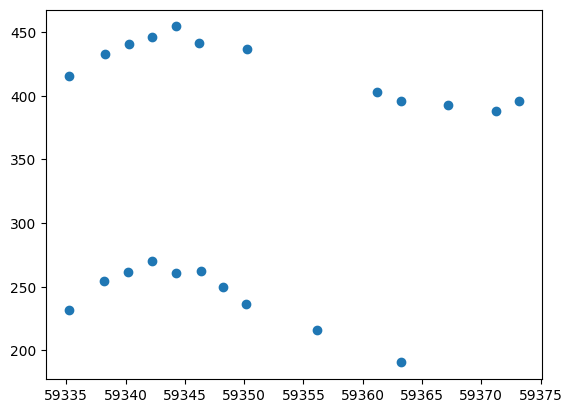

In [30]:
import matplotlib.pyplot as plt
plt.scatter(detections['mjd'], detections['flux'])
#plt.errorbar(detections['mjd'], detections['flux'], yerr=detections['flux_err'], fmt='o', color='black')
plt.show()


In [31]:
list = ['ZTF18adizksm']
detections, forced_photometry, xmatch = extract_from_db(list,engine)

In [32]:
detections['flux'] = mag2flux(detections['magpsf_corr'])
detections['flux_err'] = mag_err_2_flux_err(detections['sigmapsf_corr'], detections['magpsf_corr'])

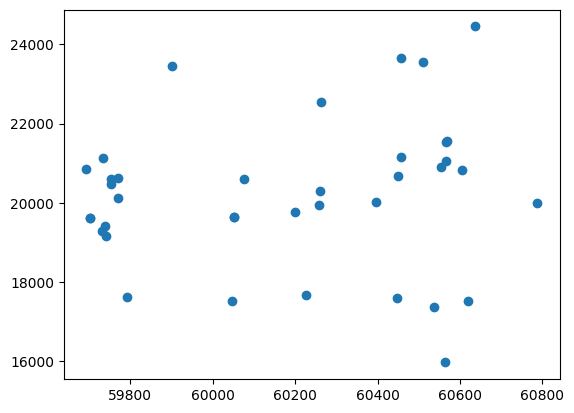

In [33]:
import matplotlib.pyplot as plt
plt.scatter(detections['mjd'], detections['flux'])
#plt.errorbar(detections['mjd'], detections['flux'], yerr=detections['flux_err'], fmt='o', color='black')
plt.show()

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def mag_ab_to_flux_uJy(mag):
    """Convert AB magnitude to flux in µJy."""
    return 10 ** ((23.9 - mag) / 2.5)

def magerr_to_fluxerr_uJy(mag, mag_err):
    """Convert AB magnitude error to flux error in µJy."""
    flux = mag_ab_to_flux_uJy(mag)
    return 0.921034 * flux * mag_err

def ztf_detections_to_lightcurve(detections, use_corrected=True, convert_to_flux=True, plot=True):
    """
    Convert ZTF detections into a clean light curve DataFrame in µJy and optionally plot it.
    
    Parameters:
        detections (list or DataFrame): List of detection dicts or a DataFrame.
        use_corrected (bool): Use corrected mag and error if available.
        convert_to_flux (bool): If True, convert AB magnitudes to flux in µJy.
        plot (bool): If True, display matplotlib plot.
        
    Returns:
        pd.DataFrame: Light curve with ['mjd', 'flux', 'flux_err', 'fid', 'filter']
    """
    df = pd.DataFrame(detections)

    # Choose magnitude columns
    mag_col = 'magpsf_corr' if use_corrected else 'magpsf'
    err_col = 'sigmapsf_corr' if use_corrected else 'sigmapsf'

    # Basic cleaning and selection
    df = df[['mjd', mag_col, err_col, 'fid']].dropna().copy()
    df = df.rename(columns={mag_col: 'mag', err_col: 'mag_err'})

    # Filter mapping
    fid_to_filter = {1: 'g', 2: 'r', 3: 'i'}
    df['filter'] = df['fid'].map(fid_to_filter)

    if convert_to_flux:
        df['flux'] = mag_ab_to_flux_uJy(df['mag'])
        df['flux_err'] = magerr_to_fluxerr_uJy(df['mag'], df['mag_err']) * 0.002
        df.drop(columns=['mag', 'mag_err'], inplace=True)
        ylabel = 'Flux [μJy]'
    else:
        df.rename(columns={'mag': 'flux', 'mag_err': 'flux_err'}, inplace=True)
        ylabel = 'Magnitude'

    df = df[['mjd', 'flux', 'flux_err', 'fid', 'filter']].reset_index(drop=True)

    # Plotting
    if plot:
        fig, ax = plt.subplots(figsize=(10, 5))
        colors = {'g': 'green', 'r': 'red', 'i': 'orange'}

        for filt in df['filter'].unique():
            sub = df[df['filter'] == filt]
            ax.errorbar(
                sub['mjd'], sub['flux'], yerr=sub['flux_err'],
                fmt='o', label=f"ZTF {filt}-band",
                color=colors.get(filt, 'gray'), alpha=0.8
            )

        ax.set_xlabel('MJD')
        ax.set_ylabel(ylabel)
        ax.set_title('ZTF Light Curve')
        if not convert_to_flux:
            ax.invert_yaxis()
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()

    return df




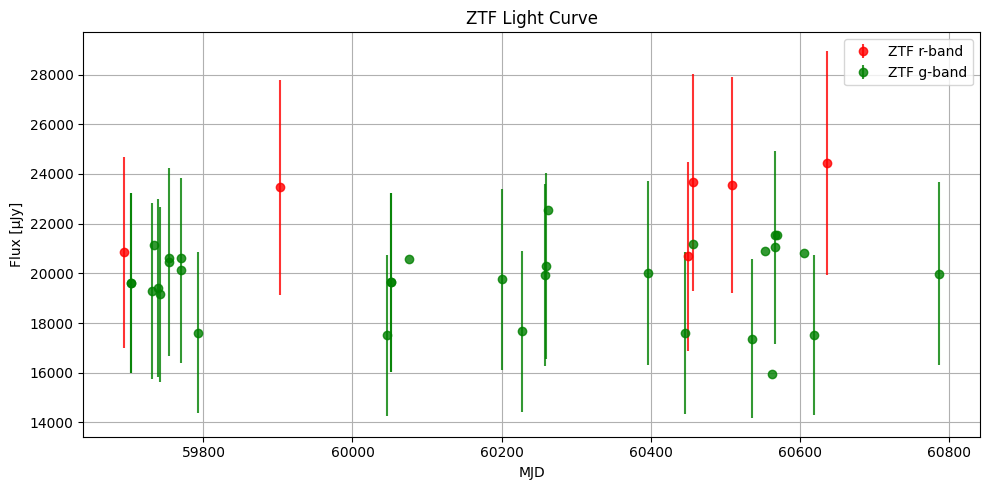

In [35]:
# detections = [...]  # list of detection dictionaries from ALeRCE or ZTF alerts
lightcurve_df = ztf_detections_to_lightcurve(detections, use_corrected=True, convert_to_flux=True, plot=True)
